# MatchFormer Inference on TUM RGB Dataset
This notebook selects two random RGB images from the TUM dataset, runs them through MatchFormer to extract features/matches, and visualizes the results.

In [1]:
import os
import glob
import random
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np

from config.defaultmf import get_cfg_defaults
from model.lightning_loftr import PL_LoFTR

# Matplotlib settings for inline display
%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 7)

/Users/siddharthraj/classes/cv/final-proj/env/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
def get_image(path, resize=(640, 480)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image from {path}.")
    img = cv2.resize(img, resize)
    img_tensor = torch.from_numpy(img).float() / 255.0
    img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)
    return img, img_tensor

In [3]:
# Load and display random 2 image paths
rgb_dir = '../tum_rgb_dataset/rgb/*.png'
all_imgs = glob.glob(rgb_dir)

img1_path, img2_path = random.sample(all_imgs, 2)
print('Selected Image 1:', img1_path)
print('Selected Image 2:', img2_path)

img1, img1_tensor = get_image(img1_path)
img2, img2_tensor = get_image(img2_path)

Selected Image 1: ../tum_rgb_dataset/rgb/1305031127.079299.png
Selected Image 2: ../tum_rgb_dataset/rgb/1305031109.511273.png


In [4]:
# Initialize Configuration
config = get_cfg_defaults()
config.MATCHFORMER.BACKBONE_TYPE = 'litela'
config.MATCHFORMER.SCENS = 'indoor'
config.MATCHFORMER.RESOLUTION = (8, 4)
config.MATCHFORMER.COARSE.D_MODEL = 192
config.MATCHFORMER.COARSE.D_FFN = 192

print('Loading MatchFormer model...')
model = PL_LoFTR(config, pretrained_ckpt='model/weights/indoor-lite-LA.ckpt')
model.eval()

Loading MatchFormer model...


2026-03-12 14:30:25.745 | INFO     | model.lightning_loftr:__init__:34 - Load 'model/weights/indoor-lite-LA.ckpt' as pretrained checkpoint


PL_LoFTR(
  (matcher): Matchformer(
    (backbone): Matchformer_LA_lite(
      (AttentionBlock1): AttentionBlock(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(1, 128, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (pos): Positional(
            (pa_conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=128)
            (sigmoid): Sigmoid()
          )
          (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        )
        (block): ModuleList(
          (0-2): 3 x Block(
            (norm1): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
            (attn): Attention(
              (q): Linear(in_features=128, out_features=128, bias=True)
              (kv): Linear(in_features=128, out_features=256, bias=True)
            )
            (drop_path): Identity()
            (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=128, out_fea

In [5]:
input_data = {'image0': img1_tensor, 'image1': img2_tensor}

print('Running interference...')
with torch.no_grad():
    model.matcher(input_data)

mkpts0 = input_data['mkpts0_f'].cpu().numpy()
mkpts1 = input_data['mkpts1_f'].cpu().numpy()
mconf = input_data['mconf'].cpu().numpy()

print(f"Found {len(mkpts0)} matches!")

Running interference...
Found 1507 matches!


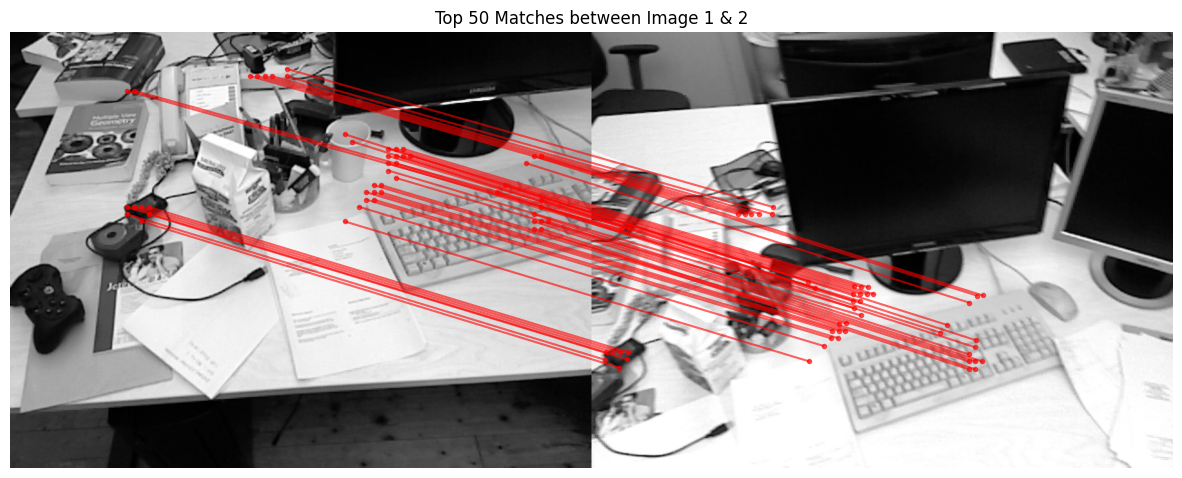

In [6]:
h1, w1 = img1.shape
h2, w2 = img2.shape
vis_img = np.zeros((max(h1, h2), w1 + w2), dtype=np.uint8)
vis_img[:h1, :w1] = img1
vis_img[:h2, w1:] = img2

plt.imshow(vis_img, cmap='gray')

idx = np.argsort(mconf)[::-1]
top_k = min(50, len(idx))

for i in range(top_k):
    pt1 = mkpts0[idx[i]]
    pt2 = mkpts1[idx[i]]
    pt2_shifted = (pt2[0] + w1, pt2[1])
    plt.plot([pt1[0], pt2_shifted[0]], [pt1[1], pt2_shifted[1]], 
             'ro-', linewidth=1.5, markersize=3, alpha=0.6)

plt.title(f'Top {top_k} Matches between Image 1 & 2')
plt.axis('off')
plt.show()

## Epipolar Geometry
Using the correspondences found by MatchFormer, we can estimate the Fundamental Matrix using RANSAC. Then, we can draw the epipolar lines on both images.

Estimated Fundamental Matrix using 1261 inliers out of 1507 matches.


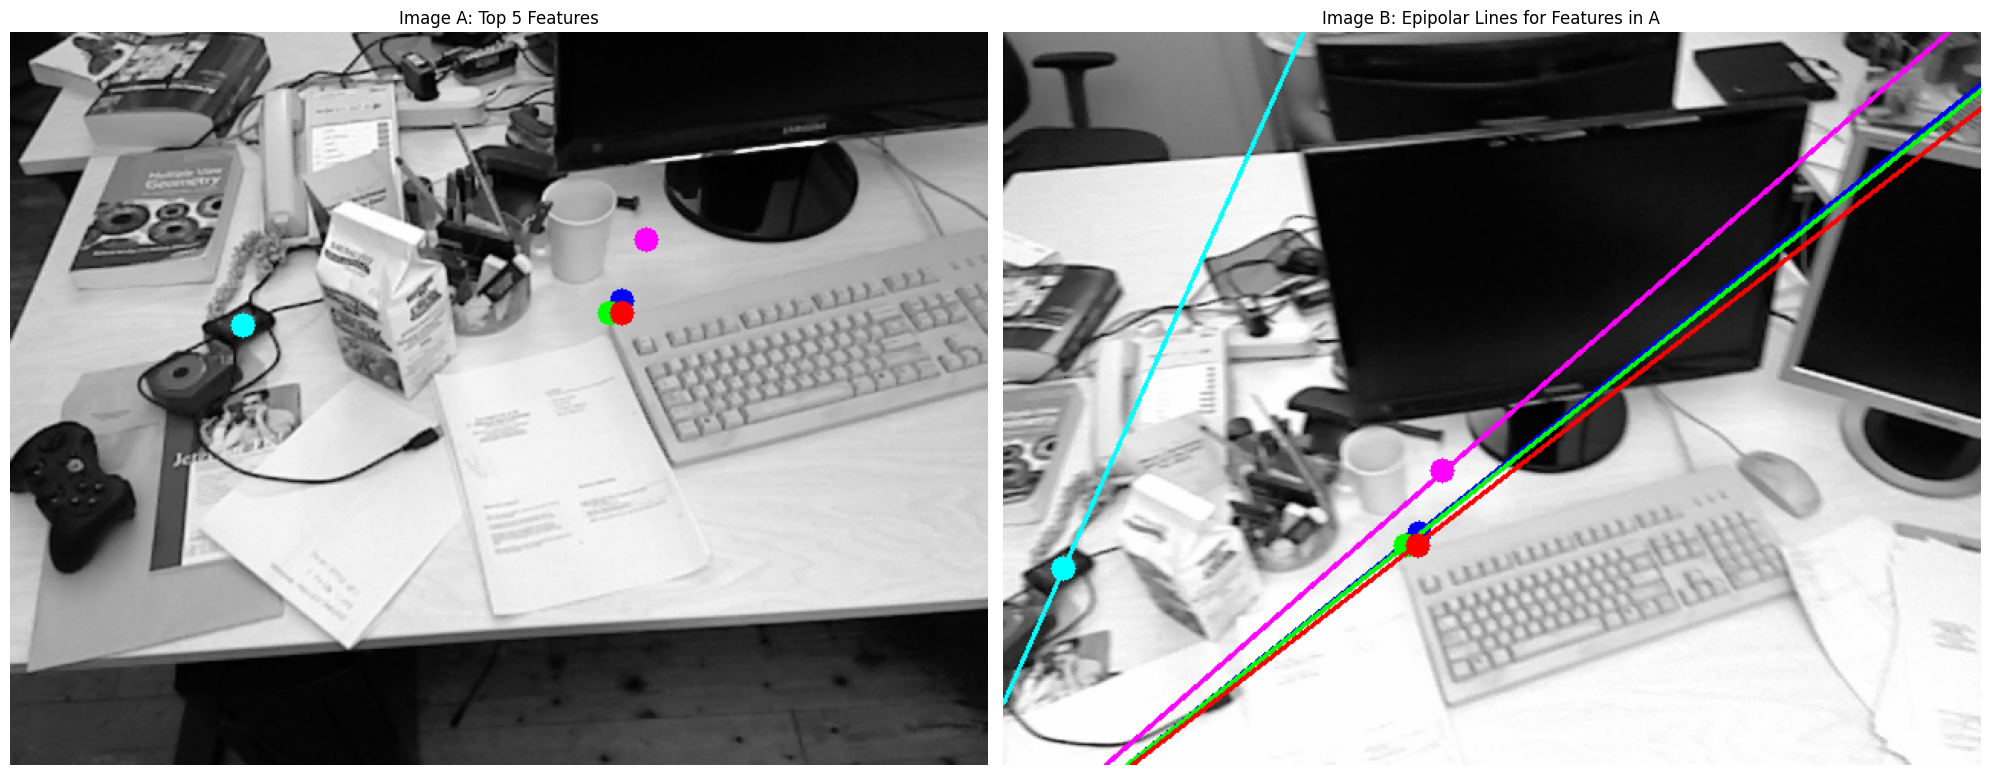

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Find Fundamental Matrix using RANSAC on all available points
F, mask = cv2.findFundamentalMat(mkpts0, mkpts1, cv2.FM_RANSAC, 3.0, 0.99)

if F is not None and mask is not None:
    inliers = mask.ravel() == 1
    pts1_inliers = mkpts0[inliers]
    pts2_inliers = mkpts1[inliers]
    conf_inliers = mconf[inliers]
    print(f"Estimated Fundamental Matrix using {len(pts1_inliers)} inliers out of {len(mkpts0)} matches.")
else:
    print("Could not find a fundamental matrix.")
    # Fallback if somehow RANSAC fails
    pts1_inliers = mkpts0
    pts2_inliers = mkpts1
    conf_inliers = mconf

# 2. Get the TOP 5 most confident matches
idx = np.argsort(conf_inliers)[::-1]
top_5_idx = idx[:5]

pts1_top = pts1_inliers[top_5_idx]
pts2_top = pts2_inliers[top_5_idx]

def draw_epipolar_lines_A_to_B(img1, img2, pts1, pts2, F):
    """
    Takes points in Image A (img1), computes the corresponding epipolar lines 
    in Image B (img2) using F, and draws both the points on A and lines/points on B.
    """
    r, c = img1.shape
    img1_color = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR) if len(img1.shape)==2 else img1.copy()
    img2_color = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR) if len(img2.shape)==2 else img2.copy()
    
    # Compute the epipolar lines in Image B corresponding to points in Image A
    # The flag '1' means points are from the *first* image (A)
    lines_in_B = cv2.computeCorrespondEpilines(pts1.reshape(-1,1,2), 1, F)
    lines_in_B = lines_in_B.reshape(-1, 3)

    # We will use distinct colors for the 5 matches
    colors = [
        (255, 0, 0),   # Red
        (0, 255, 0),   # Green
        (0, 0, 255),   # Blue
        (255, 255, 0), # Yellow
        (255, 0, 255)  # Magenta
    ]
    
    for i, (r_, pt1, pt2) in enumerate(zip(lines_in_B, pts1, pts2)):
        color = colors[i % len(colors)]
        
        # Draw the feature point in Image A
        img1_color = cv2.circle(img1_color, tuple(map(int, pt1)), 8, color, -1)
        
        # Calculate line endpoints for Image B
        x0, y0 = map(int, [0, -r_[2]/r_[1]])
        x1, y1 = map(int, [c, -(r_[2]+r_[0]*c)/r_[1]])
        
        # Draw the line and the matching point in Image B
        img2_color = cv2.line(img2_color, (x0,y0), (x1,y1), color, 2)
        img2_color = cv2.circle(img2_color, tuple(map(int, pt2)), 8, color, -1)
        
    return img1_color, img2_color

if F is not None:
    imgA, imgB = draw_epipolar_lines_A_to_B(img1, img2, pts1_top, pts2_top, F)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    ax1.imshow(cv2.cvtColor(imgA, cv2.COLOR_BGR2RGB))
    ax1.set_title('Image A: Top 5 Features')
    ax1.axis('off')
    
    ax2.imshow(cv2.cvtColor(imgB, cv2.COLOR_BGR2RGB))
    ax2.set_title('Image B: Epipolar Lines for Features in A')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()


Verified 1261 inlier matches.
Mean distance from keypoint to epipolar line: 0.9090 pixels
Max distance from keypoint to epipolar line: 2.7359 pixels


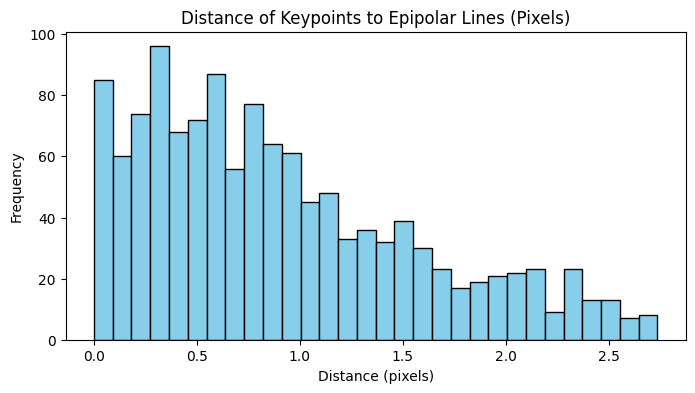

In [8]:
# 3. Verify Epipolar Constraint
# Calculate the distance from each keypoint in Image B to its corresponding epipolar line from Image A.
# The epipolar line equation is: ax + by + c = 0
# The distance from point (x0, y0) to the line is |ax0 + by0 + c| / sqrt(a^2 + b^2)

distances = []
# We will check all inliers, not just the top 5
lines_in_B_all = cv2.computeCorrespondEpilines(pts1_inliers.reshape(-1,1,2), 1, F)
lines_in_B_all = lines_in_B_all.reshape(-1, 3)

for r_, pt2 in zip(lines_in_B_all, pts2_inliers):
    a, b, c = r_
    x0, y0 = pt2
    
    dist = np.abs(a*x0 + b*y0 + c) / np.sqrt(a**2 + b**2)
    distances.append(dist)

distances = np.array(distances)
mean_dist = np.mean(distances)
max_dist = np.max(distances)

print(f"Verified {len(distances)} inlier matches.")
print(f"Mean distance from keypoint to epipolar line: {mean_dist:.4f} pixels")
print(f"Max distance from keypoint to epipolar line: {max_dist:.4f} pixels")

# Plot a histogram of the distances
plt.figure(figsize=(8, 4))
plt.hist(distances, bins=30, color='skyblue', edgecolor='black')
plt.title('Distance of Keypoints to Epipolar Lines (Pixels)')
plt.xlabel('Distance (pixels)')
plt.ylabel('Frequency')
plt.show()


## Extract Intermediate Features via Forward Hooks
We register PyTorch forward hooks to extract the feature maps from the Attention Blocks.

In [9]:
# Set up PyTorch forward hooks to extract intermediate features
feature_maps = {}
def get_activation(name):
    def hook(model, input, output):
        # depending on the layer, output could be a tuple or a tensor
        if isinstance(output, tuple):
            feature_maps[name] = output[0].detach()
        else:
            feature_maps[name] = output.detach()
    return hook

# Register hooks on AttentionBlocks
hook_handles = []
hook_handles.append(model.matcher.backbone.AttentionBlock1.register_forward_hook(get_activation('AttentionBlock1')))
hook_handles.append(model.matcher.backbone.AttentionBlock2.register_forward_hook(get_activation('AttentionBlock2')))
hook_handles.append(model.matcher.backbone.AttentionBlock3.register_forward_hook(get_activation('AttentionBlock3')))
hook_handles.append(model.matcher.backbone.AttentionBlock4.register_forward_hook(get_activation('AttentionBlock4')))

print("Registered forward hooks for AttentionBlock 1 to 4.")

# Run inference again to trigger hooks
with torch.no_grad():
    model.matcher(input_data)

# Print shapes of extracted feature maps
for k, v in feature_maps.items():
    if hasattr(v, 'shape'):
        print(f"{k} shape: {v.shape}")
    else:
        print(f"{k} type: {type(v)}")

# Remove hooks
for handle in hook_handles:
    handle.remove()


Registered forward hooks for AttentionBlock 1 to 4.
AttentionBlock1 shape: torch.Size([2, 128, 120, 160])
AttentionBlock2 shape: torch.Size([2, 192, 60, 80])
AttentionBlock3 shape: torch.Size([2, 256, 30, 40])
AttentionBlock4 shape: torch.Size([2, 512, 15, 20])


## Extract Exact Cross-Attention Matrices
Using a custom hook to recompute the exact $N \times N$ attention maps from $Q$ and $K$.

In [ ]:
# Extracting Exact Cross-Attention Matrices
# MatchFormer uses linear attention: Q, K, V
# To get the explicit N x N attention matrix (which is O(N^2) and normally avoided),
# we can compute it manually for the cross-attention layers.

import torch.nn.functional as F

cross_attn_matrices = {}

def get_cross_attn(name, layer):
    def hook(model, input, output):
        # We need to intercept Q and K from the Attention module
        # Since we can't easily hook local variables, we'll recompute the attention matrix
        # using the module's own weights and the input it received.
        
        x = input[0]
        # Same logic as Attention.forward
        B, N, C = x.shape
        MiniB = B // 2
        
        query = layer.q(x).reshape(B, N, layer.num_heads, C // layer.num_heads).permute(0, 1, 2, 3)
        kv = layer.kv(x).reshape(B, -1, 2, layer.num_heads, C // layer.num_heads).permute(2, 0, 1, 3, 4)
        
        if layer.cross == True:
            k1, k2 = kv[0].split(MiniB)
            # Cross attention: key/value come from the other image
            key = torch.cat([k2, k1], dim=0)
        else:
            return # We only want cross-attention
            
        Q = layer.feature_map(query)
        K = layer.feature_map(key)
        
        # Q: (B, N, num_heads, head_dim) -> (B, num_heads, N, head_dim)
        Q = Q.permute(0, 2, 1, 3) 
        # K: (B, N, num_heads, head_dim) -> (B, num_heads, N, head_dim)
        K = K.permute(0, 2, 1, 3)

        # Compute explicit attention matrix: A = Q @ K^T
        # K.transpose: (B, num_heads, head_dim, N)
        # attn: (B, num_heads, N_query, N_key)
        attn = torch.matmul(Q, K.transpose(-2, -1))
        
        # Apply normalization (Z in the original code)
        Z = 1 / (torch.einsum("bnld,bnd->bnl", Q, K.sum(dim=2)) + layer.eps)
        # Z: (B, num_heads, N_query). Expand to divide each row.
        attn = attn * Z.unsqueeze(-1)
        
        cross_attn_matrices[name] = attn.detach().cpu()
        
    return hook

# Register hooks on the Attention module within each cross-attention Block
hook_handles_attn = []
# Stage 1 has cross=True on the 3rd block (index 2)
hook_handles_attn.append(model.matcher.backbone.AttentionBlock1.block[2].attn.register_forward_hook(
    get_cross_attn('stage1_cross', model.matcher.backbone.AttentionBlock1.block[2].attn)))

# Stage 2 has cross=True on the 3rd block (index 2)
hook_handles_attn.append(model.matcher.backbone.AttentionBlock2.block[2].attn.register_forward_hook(
    get_cross_attn('stage2_cross', model.matcher.backbone.AttentionBlock2.block[2].attn)))

# Stage 3 has cross=True on 2nd and 3rd blocks (index 1, 2)
hook_handles_attn.append(model.matcher.backbone.AttentionBlock3.block[1].attn.register_forward_hook(
    get_cross_attn('stage3_cross_1', model.matcher.backbone.AttentionBlock3.block[1].attn)))
hook_handles_attn.append(model.matcher.backbone.AttentionBlock3.block[2].attn.register_forward_hook(
    get_cross_attn('stage3_cross_2', model.matcher.backbone.AttentionBlock3.block[2].attn)))

# Stage 4 has cross=True on 2nd and 3rd blocks (index 1, 2)
hook_handles_attn.append(model.matcher.backbone.AttentionBlock4.block[1].attn.register_forward_hook(
    get_cross_attn('stage4_cross_1', model.matcher.backbone.AttentionBlock4.block[1].attn)))
hook_handles_attn.append(model.matcher.backbone.AttentionBlock4.block[2].attn.register_forward_hook(
    get_cross_attn('stage4_cross_2', model.matcher.backbone.AttentionBlock4.block[2].attn)))

print("Registered cross-attention specific hooks.")

with torch.no_grad():
    model.matcher(input_data)

for k, v in cross_attn_matrices.items():
    print(f"{k} attention matrix shape: {v.shape}")

for handle in hook_handles_attn:
    handle.remove()
